# TClab CLP PID FF
Import

In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors
import os
import time
from datetime import datetime
import tclab

from package_DBR import *
from Package_Lab import *

Set Graph

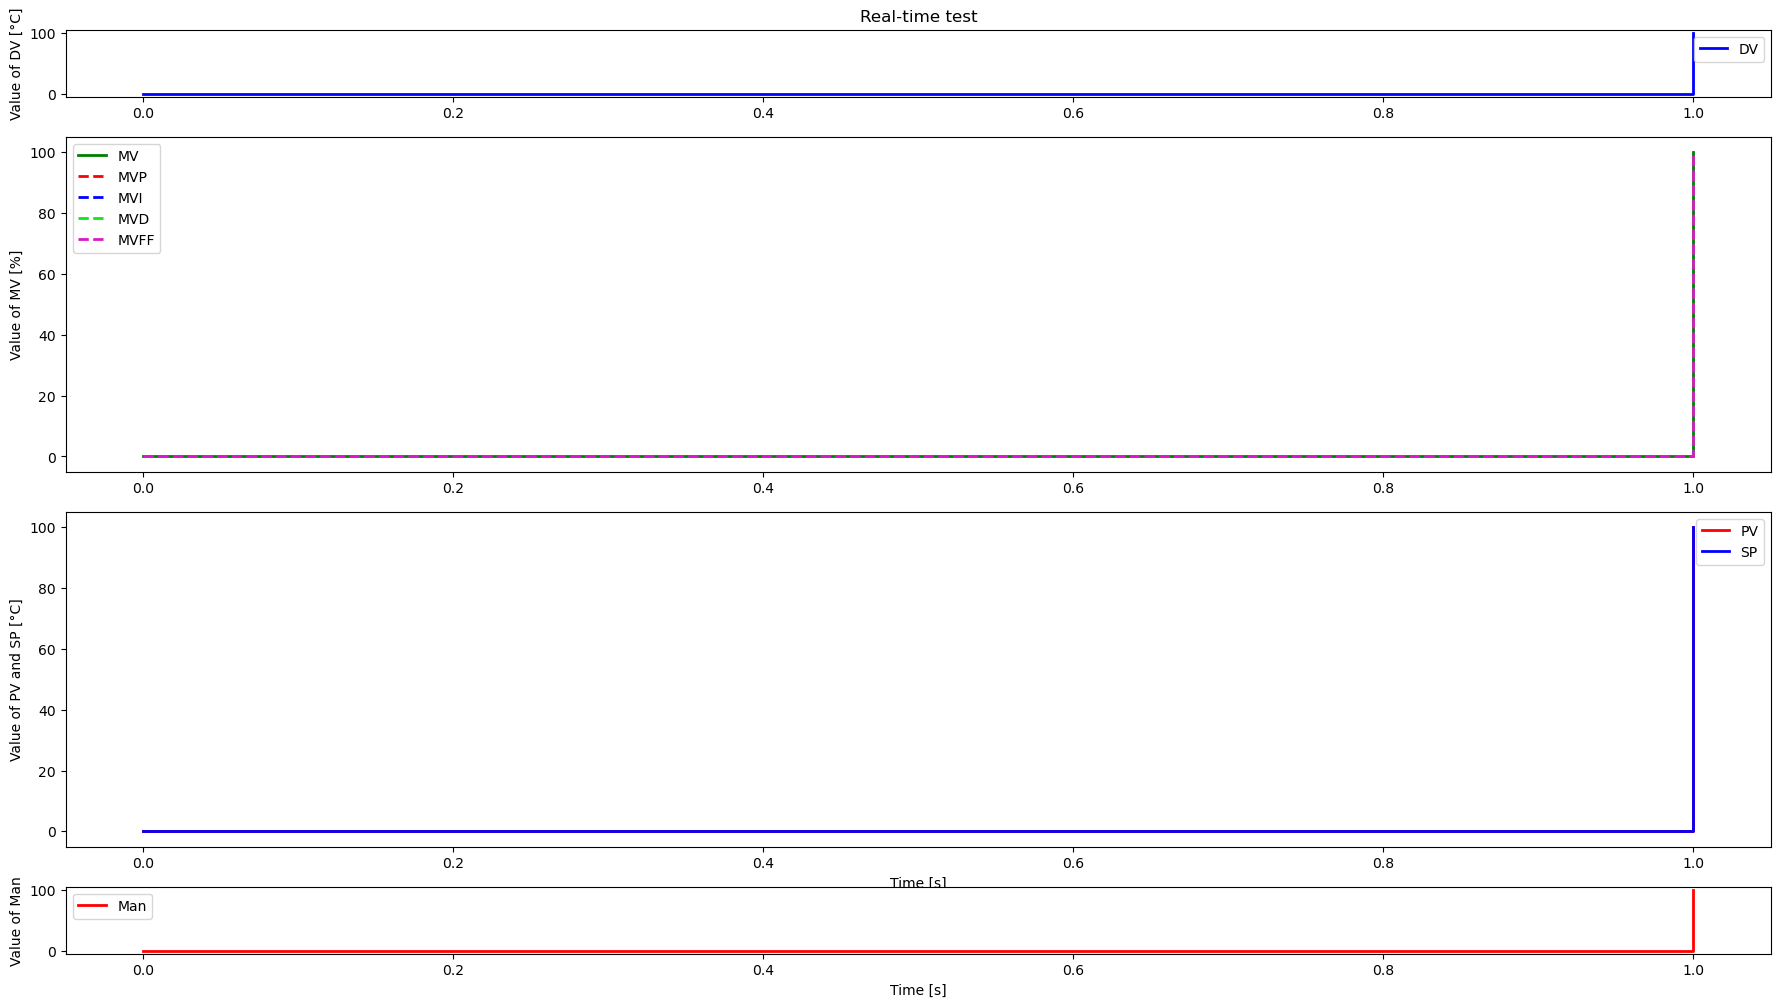

In [2]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(15,9),
                        gridspec_kw={'height_ratios': [1, 5, 5, 1]})
fig.set_figheight(12)
fig.set_figwidth(22)

l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='DV',where='post')
ax1.set_ylabel('Value of DV [°C]')
ax1.set_title('Real-time test')
ax1.legend(loc='best')

l2, = ax2.step([0,1],[0,100],'g-',linewidth=2,label='MV',where='post')
l6, = ax2.step([0,1],[0,100], color='r', linestyle='--', linewidth=2, label='MVP', where='post')
l7, = ax2.step([0,1],[0,100], color='b', linestyle='--', linewidth=2, label='MVI', where='post')
l8, = ax2.step([0,1],[0,100], color="#11e618", linestyle='--', linewidth=2, label='MVD', where='post')
l9, = ax2.step([0,1],[0,100], color="#d818c5", linestyle='--', linewidth=2, label='MVFF', where='post')
ax2.set_ylabel('Value of MV [%]')
ax2.legend(loc='best')

l3, = ax3.step([0,1],[0,100],'r-',linewidth=2,label='PV',where='post')
l4, = ax3.step([0,1],[0,100],'b-',linewidth=2,label='SP',where='post')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Value of PV and SP [°C]')
ax3.legend(loc='best') 

l5, = ax4.step([0,1],[0,100],'r-',linewidth=2,label='Man',where='post')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Value of Man')
ax4.legend(loc='best') 

Scenario

In [ ]:
Scenario = 2
# 1 - NO FF and Man
# 2 - FF and Man
# 3 - NO FF and NO Man
# 4 - FF and NO Man

Set list

In [4]:
TSim = 2500
Ts = 1
N = int(TSim/Ts) + 1

PV0 = 77

# Path
if Scenario == 1: # 1 - NO FF and Man
    name = "NO_FF_and_Man"
    FF = False
    MVFFPath = {0:0 , TSim: 0}
    SPPath = {0: PV0, 750:87, TSim: 87}
    DVPath = {0: 50, 1500:60, TSim: 60}
    ManPath = {0: True, TSim:True}
    MVManPath = {0: 50, TSim: 50}

elif Scenario == 2: # 2 - FF and Man
    name = "FF_and_Man"
    FF = True
    SPPath = {0: PV0, 750:87, TSim: 87}
    DVPath = {0: 50, 1500:60, TSim: 60}
    ManPath = {0: True, TSim:True}
    MVManPath = {0: 50, TSim: 50}

elif Scenario == 3: # 3 - NO FF and NO Man
    name = "NO_FF_and_NO_Man"
    FF = False
    MVFFPath = {0:0 , TSim: 0}
    SPPath = {0: PV0, 750:87, TSim: 87}
    DVPath = {0: 50, 1500:60, TSim: 60}
    ManPath = {0: True,225:False, TSim:False}
    MVManPath = {0: 50, 225: 0 , TSim: 0}

elif Scenario == 4: # 4 - FF and NO Man
    name = "FF_and_NO_Man"
    FF = True
    SPPath = {0: PV0, 750:87, TSim: 87}
    DVPath = {0: 50, 1500:60, TSim: 60}
    ManPath = {0: True,225:False, TSim:False}
    MVManPath = {0: 50, 225: 0 , TSim: 0}

t = []
SP = []

MV = []
MVDelay = []

DV = []
MVFFDelay = []
MVFF_FLL = []
MVFF = []

MVMan = []
MVP = []
MVI = []
MVD = []
PV = []
E = []
Man = []

# Parameters
DV0 = 50
MV0 = 50
gamma = 0.9
Kc = 0
Ti = 0
Td = 0
alpha = 0.9
MVMin = 0
MVMax = 100
ManFF = False
Kd = 0.618599605156834
Kp = 0.540610574655048
T1d = 147.5486385332903
T2d = 36.22565494631446
T1p = 130.5026136090156
T2p = 35.46518028608689
Thetap = 14.348568183245677
Thetad = 13.351904889062693

Run simulation

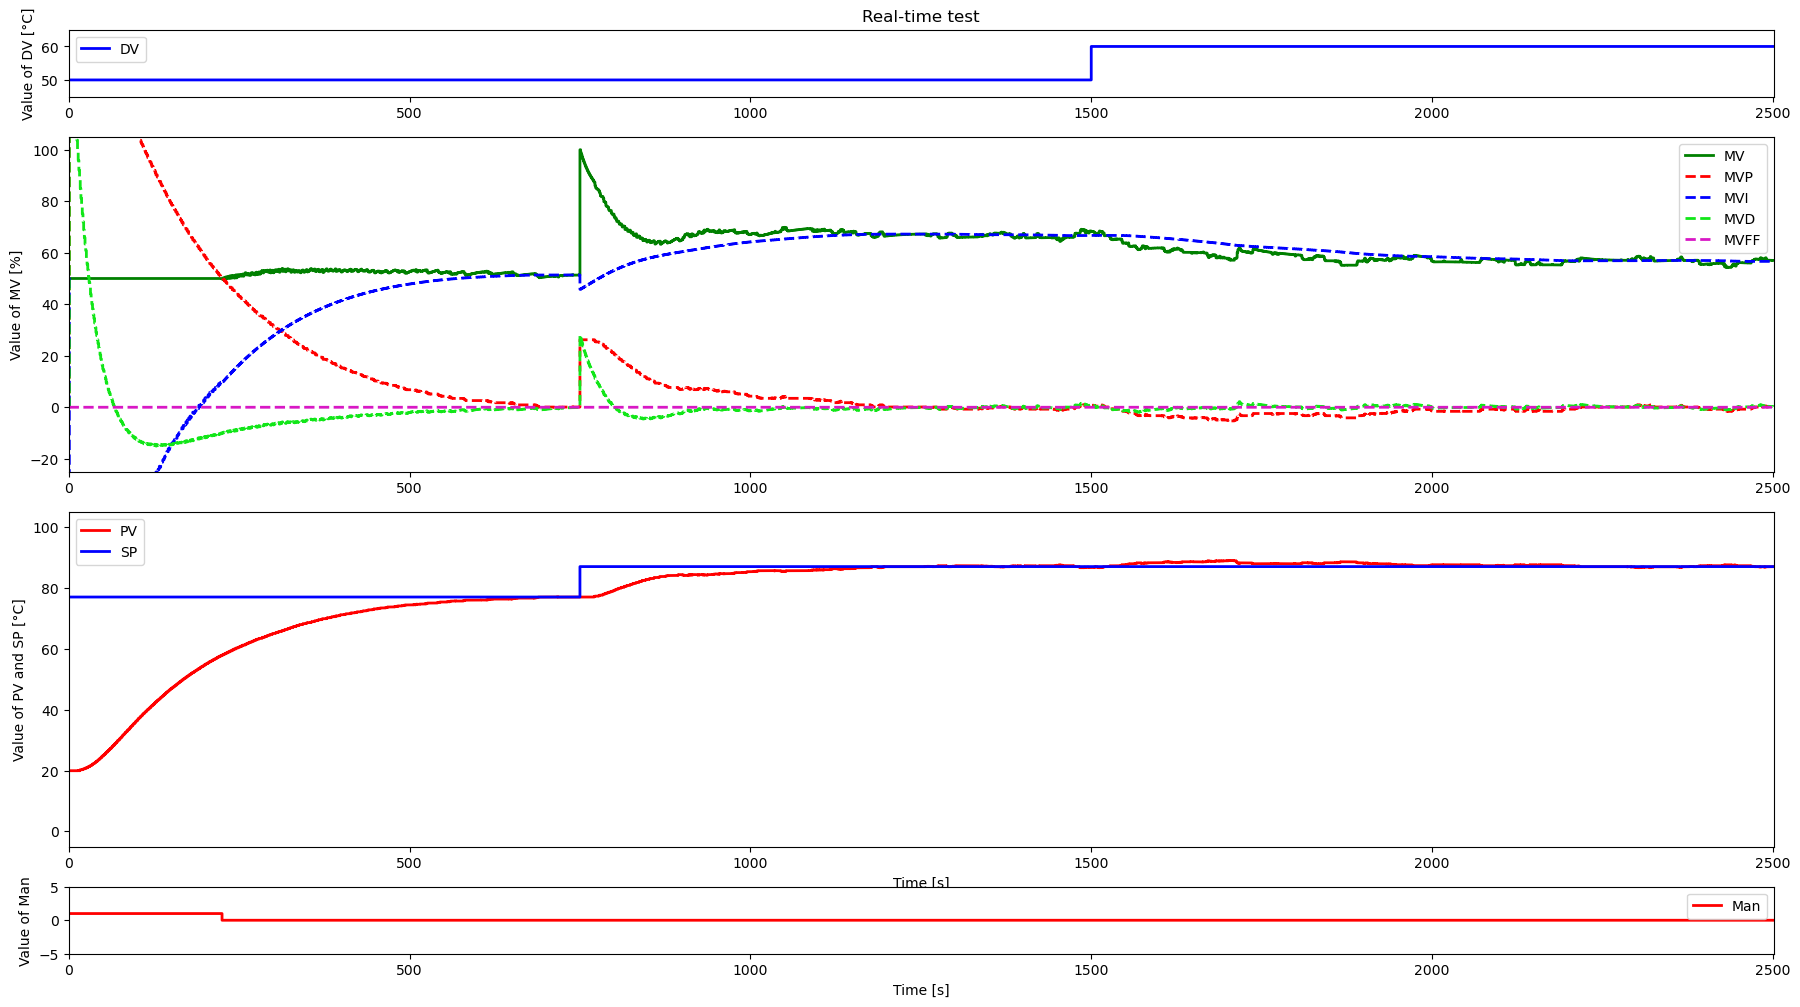

TCLab disconnected successfully.
help


In [5]:
lab = tclab.TCLab()

for i in range(0,N):

    t.append(i*Ts)
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(DVPath,t,DV)
    SelectPath_RT(ManPath,t,Man)
    SelectPath_RT(MVManPath,t,MVMan)

    if t[-1] == 0:
        last_time = time.time()

    #MVFF
    if FF == True:
        Delay_RT(DV-DV0*np.ones_like(DV),max(0,Thetad-Thetap),Ts,MVFFDelay)
        LL_RT(MVFFDelay,-Kd/Kp,Ts,T1p,T1d,MVFF_FLL)
        LL_RT(MVFF_FLL,1,Ts,T2p,T2d,MVFF,0)
    else:
        SelectPath_RT(MVFFPath,t,MVFF)

    Kc, Ti, Td = IMC_TUNING(Kp,gamma,T1p,T2p)

    PID_RT(SP,PV,Man,MVMan,MVFF,Kc,Ti,Td,alpha,Ts,MVMin,MVMax,MV,MVP,MVI,MVD,E,ManFF,PV0)

    lab.Q1(MV[-1])
    lab.Q2(DV[-1])

    PV.append(lab.T1)

    l1.set_data(t,DV)
    l2.set_data(t,MV)
    l3.set_data(t,PV)
    l4.set_data(t,SP)
    l5.set_data(t,Man)
    l6.set_data(t,MVP)
    l7.set_data(t,MVI)
    l8.set_data(t,MVD)
    l9.set_data(t,MVFF)

    clear_output(wait=True)    

    ax1.set_xlim(0, t[-1]+1)
    ax2.set_xlim(0, t[-1]+1)
    ax3.set_xlim(0, t[-1]+1)
    ax4.set_xlim(0, t[-1]+1)

    if i > 1:
        ax1.set_ylim(myRound(np.min(DV),5)-5, myRound(np.max(DV),5)+5)
        ax2.set_ylim(-25, 105)
        ax3.set_ylim(-5, 105)
        ax4.set_ylim(myRound(np.min(Man),5)-5, myRound(np.max(Man),5)+5) 

    display(fig)

    now = time.time()
    delta = now - last_time
    
    time.sleep(np.max([0, Ts - delta]))
    last_time = time.time()   

lab.close()

now = datetime.now()
date_time = now.strftime("%Y-%m-%d-%Hh%M")

t = np.array(t) 
MV = np.array(MV)
PV = np.array(PV)
DV = np.array(DV)
MVP = np.array(MVP)
MVI = np.array(MVI)
MVD = np.array(MVD)   
MVFF = np.array(MVFF)
Man = np.array(Man)      

my_data = np.vstack((t.T,MV.T,PV.T,DV.T,MVP.T,MVI.T,MVD.T,MVFF.T,Man.T))
my_data = my_data.T
nameFile = 'Data/CLP_experiment_on_' + date_time +'('+name+ ').txt'
if not os.path.exists('Data'):
    os.makedirs('Data')
np.savetxt(nameFile,my_data,delimiter=',',header='t,MV,PV,DV,MVP,MVI,MVD,MVFF,Man',comments='')        


if not os.path.exists('Plots'):
    os.makedirs('Plots')

fig.tight_layout()

titleName = 'CLP_experiment_on_' + date_time+ '('+name+ ')'
fig.savefig(os.path.join('Plots', titleName + '.png'), transparent=True)
fig.savefig(os.path.join('Plots', titleName + '.pdf'), transparent=True)
print("help")
